# Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from scipy.signal import correlate
from scipy.interpolate import interp1d
from hapi import *
from pylab import plot
import pickle
from scipy.stats import chi2
from scipy.stats import norm
import matplotlib.ticker as ticker
from pathlib import Path
import gc
from concurrent.futures import ProcessPoolExecutor, as_completed
# from astropy.constants import constants as const


# from bin_spec import bin_spectrum
import seaborn as sns

%matplotlib inline

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [2]:
# data_path = '/Users/zaniaccollins/Research/SGL/sgl_science_case/data/spectra_xsc_atm'

# data_path = '/home/zaniacco/orcd/pool/sgl_science_case/spectra_dict_cache_dwn1e-4_behemoth_test'
# data_path_test = '/home/zaniacco/orcd/pool/sgl_science_case/spectra_dict_cache_dwn1e-4_behemoth_test'


data_path = '/home/zaniacco/orcd/pool/sgl_science_case/spectra_dict_cache_hydrocarbons'
data_path_test = '/home/zaniacco/orcd/pool/sgl_science_case/spectra_dict_cache_hydrocarbons'

# Helper functions

In [3]:
def get_molecule_id(molecule_name):
    """Return (M, common_local_I) for a molecule by name"""
    for (M, I), data in hapi.ISO.items():
        if data[4].upper() == molecule_name.upper():   # data[4] is the molecule name like 'N2O'
            return M, I   # returns first (main) isotopologue
    raise ValueError(f"Molecule {molecule_name} not found in hapi.ISO")

def cross_correlate_spectra(template_spectra, test_spectra, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation between two spectra.
    Returns a dictionary with all relevant results.
    """
    # Zero-mean normalization
    template_norm = (template_spectra - np.mean(template_spectra)) / np.std(template_spectra)
    test_norm     = (test_spectra     - np.mean(test_spectra))     / np.std(test_spectra)
    
    # Cross-correlation
    ccf = correlate(template_norm, test_norm, mode='full')
    ccf /= np.sqrt(np.sum(template_norm**2) * np.sum(test_norm**2))
    
    # Lags
    if lags is None:
        lags = np.arange(-len(template_norm) + 1, len(template_norm))
    
    # Basic statistics
    max_corr = np.max(ccf)
    peak_idx = np.argmax(ccf)
    
    # Noise estimation from wings (excluding central peak)
    window_size = int(0.15 * len(ccf))
    noise_mask = np.ones(len(ccf), dtype=bool)
    noise_mask[max(0, peak_idx - window_size): min(len(ccf), peak_idx + window_size)] = False
    noise_values = ccf[noise_mask]
    noise_std = np.std(noise_values) if len(noise_values) > 20 else np.std(ccf)
    
    # SNR array
    cc_snr = ccf / noise_std if noise_std > 0 else np.zeros_like(ccf)
    
    results = {
        'ccf': ccf,
        'lags': lags,
        'max_correlation': max_corr,
        'peak_lag': lags[peak_idx],
        'noise_std': noise_std,
        'template_norm': template_norm,
        'test_norm': test_norm,
    }
    
    if return_full:
        results['ccf_clean'] = np.clip(np.nan_to_num(ccf, nan=0.0), 0, None)
    
    return results

def compute_log_likelihood(template, test):
    """
    Continuum-subtracted Gaussian log-likelihood (up to an additive constant).
    Model: test ≈ a * template + noise
    logL = -N/2 * log(mean residual^2)
    """
    f = np.asarray(template, dtype=float)
    g = np.asarray(test, dtype=float)
    
    m = np.isfinite(f) & np.isfinite(g)
    f, g = f[m], g[m]

    f = f - np.mean(f)
    g = g - np.mean(g)

    N = f.size
    denom = np.dot(f, f)

    if denom <= 0 or N < 2:
        return -np.inf, 0.0

    # a = np.dot(f, g) / denom
    a = 1
    
    #Compute variances
    sf2 = np.dot(f,f)/N
    sg2 = np.dot(g,g)/N
    R = np.dot(f,g)/N

    arg = sf2 - 2.0 * a * R + a**2 * sg2
    
    # residual = g - a * f
    # sigma2 = np.dot(residual, residual) / N

    logL = -0.5 * N * np.log(arg)
    return logL, a

def load_scenario(scenario_key, out_dir=None):

    path = os.path.join(out_dir, f"{scenario_key}.pkl")
    with open(path, "rb") as f:
        return pickle.load(f)
    
def check_spec(name, x):
    x = np.asarray(x, float)
    print(name,
          "len", len(x),
          "nan", np.isnan(x).sum(),
          "inf", np.isinf(x).sum(),
          "std", np.nanstd(x),
          "min/max", np.nanmin(x), np.nanmax(x))
    
def _is_blackbody_name(name: str) -> bool:
    s = str(name).strip().upper()
    return s in {"BLACKBODY", "BB", "NONE", "CONTINUUM", "PLANCK"}


def _interp_flux_to_grid(wl_src, flux_src, wl_tgt):
    """Linear interpolation of flux onto wl_tgt. No extrapolation spikes."""
    wl_src = np.asarray(wl_src, dtype=np.float64).ravel()
    flux_src = np.asarray(flux_src, dtype=np.float64).ravel()
    wl_tgt = np.asarray(wl_tgt, dtype=np.float64).ravel()

    order = np.argsort(wl_src)
    wl_src, flux_src = wl_src[order], flux_src[order]
    # drop duplicate wavelengths
    _, uniq = np.unique(wl_src, return_index=True)
    wl_src, flux_src = wl_src[uniq], flux_src[uniq]

    return np.interp(wl_tgt, wl_src, flux_src, left=np.nan, right=np.nan)


# def cross_correlate_two_templates(template_A, template_B, test_scenario, in_dir = data_path, wl_min = None, wl_max = None, verbose = True):
#     """
#     Cross-correlate two specific clean templates against the noisy versions
#     of a single test scenario.
#     """  

#     if verbose:
#         print(f"Loading scenarios...")
#     data_A = load_scenario(template_A, in_dir)
#     data_B = load_scenario(template_B, in_dir)
#     data_test = load_scenario(test_scenario, in_dir)
    

#     # Only use resolutions that exist in all three
#     common_resolutions = sorted(
#         set(data_A.keys()) & set(data_B.keys()) & set(data_test.keys())
#     )
#     if verbose:
#         print('Common resolutions: ', common_resolutions)
#     if verbose:
#         if wl_min is not None or wl_max is not None:
#             print(f"Wavelength window: [{wl_min}, {wl_max}] µm")

#     records = []
    
#     # Checking if blackbody to see if interpolation is needed
#     A_is_bb = _is_blackbody_name(template_A)
#     B_is_bb = _is_blackbody_name(template_B)
    
#     for r in common_resolutions:
#         # Check that everything we need exists
#         wl = np.asarray(data_A[r]["wavelength_grid"], dtype=np.float64)

#         # mask: finite, optional window, drop binning edge artifacts
#         m = np.isfinite(wl)
#         if wl_min is not None:
#             m &= wl >= float(wl_min)
#         if wl_max is not None:
#             m &= wl <= float(wl_max)

#         # also require same length grids on B and test
#         wl_b = np.asarray(data_B[r]["wavelength_grid"], dtype=np.float64)
#         wl_t = np.asarray(data_test[r]["wavelength_grid"], dtype=np.float64)
#         if len(wl_b) != len(wl) or len(wl_t) != len(wl):
#             print(f"  skip R={r}: wavelength grid length mismatch")
#             continue

#         # n_pix = int(np.count_nonzero(m))
#         # if n_pix < 10:
#         #     print(f"  skip R={r}: only {n_pix} pixels in window")
#         #     continue

#         template_A_spec = np.asarray(data_A[r]["flux_clean"], dtype=np.float64)[m]
#         template_B_spec = np.asarray(data_B[r]["flux_clean"], dtype=np.float64)[m]
        
#         if verbose:
#             check_spec("A", template_A_spec)
#             check_spec("B", template_B_spec)

#         # Loop over noisy versions of the test scenario at this resolution
#         for key in data_test[r]:
#             if not key.startswith('flux_snr'):
#                 continue

#             noisy_spec = np.asarray(data_test[r][key], dtype=np.float64)[m]
#             if verbose:
#                 check_spec("data", noisy_spec)
            
#             snr_value = int(key.split('snr')[-1])
#             if verbose:
#                 print(f'Cross correlating at R = {r}, snr = {snr_value}')

#             if len(template_A_spec) != len(noisy_spec):
#                 continue

#             # Log-likelihoods
#             log_lik_A, _ = compute_log_likelihood(template_A_spec, noisy_spec)
#             log_lik_B, _ = compute_log_likelihood(template_B_spec, noisy_spec)

#             delta_ll = log_lik_B - log_lik_A
#             # delta_ll /= len(template_A_spec) #Convert to log_likelihood per bin

#             ts = 2.0 * delta_ll
#             p = chi2.sf(ts, df=1)
#             if verbose:
#                 print(p)

#             if delta_ll > 0: 
#                 sigma = (2.0 * delta_ll) ** 0.5 #Chi-squared for 1 d.o.f. maps to sqrt(deltall)
#             elif delta_ll < 0:
#                 sigma = 0.0          # B not preferred → no detection of B over A
#                 # optional: sigma_A = (2.0 * (-delta_ll)) ** 0.5  # how strongly A wins
#             else:
#                 sigma = 0.0
#             if verbose:
#                 print(
#                     f"R={r} SNR={snr_value}  "
#                     f"logL_A={log_lik_A:.6e}  logL_B={log_lik_B:.6e}  "
#                     f"delta={delta_ll:.6e}  sigma={sigma}"
#                 )

#             # if r == 1e7:
#             #     print('----------------------------------')
#             #     print(f"  log_lik_A = {log_lik_A:.3f}")
#             #     print(f"  log_lik_B = {log_lik_B:.3f}")
#             #     print(f"  delta    = {log_lik_B - log_lik_A:.3f}")

#             # delta_ll = log_lik_B - log_lik_A
#             # ts = 2 * delta_ll
#             # p = chi2.sf(ts, df=1)
#             # sigma = norm.isf(p / 2.0)

#             # print(f'sigma = {sigma}')

#             records.append({
#                 'resolution': r,
#                 'snr': snr_value,
#                 'delta_logL': delta_ll,
#                 'sigma': sigma,
#             })

#             del noisy_spec
#             gc.collect()

#         del template_A_spec, template_B_spec
#         gc.collect()

#     # Free memory
#     del data_A, data_B, data_test
#     gc.collect()

#     df = pd.DataFrame(records)
#     # print(f"Generated {len(df)} records for {template_A} vs {template_B}")
#     return df

def _is_blackbody_name(name: str) -> bool:
    s = str(name).strip().upper()
    return s in {"BLACKBODY", "BB", "NONE", "CONTINUUM", "PLANCK"}


def _interp_flux_to_grid(wl_src, flux_src, wl_tgt):
    """Linear interpolation of flux onto wl_tgt. No extrapolation spikes."""
    wl_src = np.asarray(wl_src, dtype=np.float64).ravel()
    flux_src = np.asarray(flux_src, dtype=np.float64).ravel()
    wl_tgt = np.asarray(wl_tgt, dtype=np.float64).ravel()

    order = np.argsort(wl_src)
    wl_src, flux_src = wl_src[order], flux_src[order]
    # drop duplicate wavelengths
    _, uniq = np.unique(wl_src, return_index=True)
    wl_src, flux_src = wl_src[uniq], flux_src[uniq]

    return np.interp(wl_tgt, wl_src, flux_src, left=np.nan, right=np.nan)


def cross_correlate_two_templates(
    template_A,
    template_B,
    test_scenario,
    in_dir=data_path,
    wl_min=None,
    wl_max=None,
    verbose=True,
):
    """
    Cross-correlate two clean templates against noisy versions of one test scenario.
    If a template is a blackbody and its wavelength grid mismatches, interpolate
    that blackbody onto the test grid (blackbody only).
    """
    if verbose:
        print("Loading scenarios...")
    data_A = load_scenario(template_A, in_dir)
    data_B = load_scenario(template_B, in_dir)
    data_test = load_scenario(test_scenario, in_dir)

    common_resolutions = sorted(
        set(data_A.keys()) & set(data_B.keys()) & set(data_test.keys())
    )
    if verbose:
        print("Common resolutions: ", common_resolutions)
        if wl_min is not None or wl_max is not None:
            print(f"Wavelength window: [{wl_min}, {wl_max}] µm")

    A_is_bb = _is_blackbody_name(template_A)
    B_is_bb = _is_blackbody_name(template_B)

    records = []
    for r in common_resolutions:
        # Reference grid = test scenario (always)
        wl_t = np.asarray(data_test[r]["wavelength_grid"], dtype=np.float64)
        flux_t_clean = np.asarray(data_test[r]["flux_clean"], dtype=np.float64)

        wl_a = np.asarray(data_A[r]["wavelength_grid"], dtype=np.float64)
        flux_a = np.asarray(data_A[r]["flux_clean"], dtype=np.float64)
        wl_b = np.asarray(data_B[r]["wavelength_grid"], dtype=np.float64)
        flux_b = np.asarray(data_B[r]["flux_clean"], dtype=np.float64)

        # --- align A ---
        if len(wl_a) == len(wl_t) and np.allclose(wl_a, wl_t, rtol=0, atol=1e-12):
            flux_a_on_t = flux_a
        elif A_is_bb:
            if verbose:
                print(f"R={r}: interpolating blackbody template A → test grid")
            flux_a_on_t = _interp_flux_to_grid(wl_a, flux_a, wl_t)
        else:
            print(f" skip R={r}: template A grid mismatch and not blackbody")
            continue

        # --- align B ---
        if len(wl_b) == len(wl_t) and np.allclose(wl_b, wl_t, rtol=0, atol=1e-12):
            flux_b_on_t = flux_b
        elif B_is_bb:
            if verbose:
                print(f"R={r}: interpolating blackbody template B → test grid")
            flux_b_on_t = _interp_flux_to_grid(wl_b, flux_b, wl_t)
        else:
            print(f" skip R={r}: template B grid mismatch and not blackbody")
            continue

        # wavelength mask on the *test* grid
        m = np.isfinite(wl_t) & np.isfinite(flux_a_on_t) & np.isfinite(flux_b_on_t)
        if wl_min is not None:
            m &= wl_t >= float(wl_min)
        if wl_max is not None:
            m &= wl_t <= float(wl_max)

        if np.count_nonzero(m) < 10:
            print(f" skip R={r}: only {np.count_nonzero(m)} pixels in window")
            continue

        template_A_spec = flux_a_on_t[m]
        template_B_spec = flux_b_on_t[m]

        if verbose:
            check_spec("A", template_A_spec)
            check_spec("B", template_B_spec)

        for key in data_test[r]:
            if not key.startswith("flux_snr"):
                continue

            noisy_spec = np.asarray(data_test[r][key], dtype=np.float64)[m]
            if not np.all(np.isfinite(noisy_spec)):
                # drop any residual non-finite bins together
                good = np.isfinite(noisy_spec)
                if np.count_nonzero(good) < 10:
                    continue
                ta = template_A_spec[good]
                tb = template_B_spec[good]
                ns = noisy_spec[good]
            else:
                ta, tb, ns = template_A_spec, template_B_spec, noisy_spec

            if verbose:
                check_spec("data", ns)

            snr_value = int(key.split("snr")[-1])
            if verbose:
                print(f"Cross correlating at R = {r}, snr = {snr_value}")

            if len(ta) != len(ns):
                continue

            log_lik_A, _ = compute_log_likelihood(ta, ns)
            log_lik_B, _ = compute_log_likelihood(tb, ns)
            delta_ll = log_lik_B - log_lik_A

            if delta_ll > 0:
                sigma = (2.0 * delta_ll) ** 0.5
            else:
                sigma = 0.0

            if verbose:
                print(
                    f"R={r} SNR={snr_value} "
                    f"logL_A={log_lik_A:.6e} logL_B={log_lik_B:.6e} "
                    f"delta={delta_ll:.6e} sigma={sigma}"
                )

            records.append({
                "resolution": r,
                "snr": snr_value,
                "delta_logL": delta_ll,
                "sigma": sigma,
            })

            del noisy_spec
            gc.collect()

        del template_A_spec, template_B_spec
        gc.collect()

    del data_A, data_B, data_test
    gc.collect()
    return pd.DataFrame(records)


def cross_correlate_blackbody_test(
    template_A,
    template_B,
    test_scenario,
    in_dir=data_path_test,
    wl_min=None,
    wl_max=None,
    verbose=True,
):

    data_A = load_scenario(template_A, in_dir)
    data_B = load_scenario(template_B, in_dir)
    data_test = load_scenario(test_scenario, in_dir)

    common_resolutions = sorted(
        set(data_A.keys()) & set(data_B.keys()) & set(data_test.keys())
    )
    if verbose:
        print("Common resolutions:", common_resolutions)

    records = []
    for r in common_resolutions:
        if r < 1.05e5:
            wl = np.asarray(data_A[r]["wavelength_grid"], dtype=np.float64)
            m = np.isfinite(wl)
            if wl_min is not None:
                m &= wl >= float(wl_min)
            if wl_max is not None:
                m &= wl <= float(wl_max)

            # if int(np.count_nonzero(m)) < 10:
            #     if verbose:
            #         print(f" skip R={r}: too few pixels")
            #     continue

            for key in data_test[r]:
                if not key.startswith("flux_snr"):
                    continue

                # ONE shared observation
                data_spec = np.asarray(data_test[r][key], dtype=np.float64)[m]
                template_A_spec = np.asarray(data_A[r][key], dtype=np.float64)[m]
                template_B_spec = np.asarray(data_B[r][key], dtype=np.float64)[m]
                snr_value = int(key.split("snr")[-1])

                if not (len(template_A_spec) == len(template_B_spec) == len(data_spec)):
                    continue

                log_lik_A, _ = compute_log_likelihood(template_A_spec, data_spec)
                log_lik_B, _ = compute_log_likelihood(template_B_spec, data_spec)
                delta_ll = log_lik_B - log_lik_A
                delta_ll_per_bin = delta_ll / len(data_spec)

                # signed diagnostic only — NOT a calibrated false-alarm rate
                signed_sigma = np.sign(delta_ll) * np.sqrt(2.0 * abs(delta_ll))

                if verbose:
                    print(
                        f"R={r} SNR={snr_value}  "
                        f"logL_A={log_lik_A:.6e}  logL_B={log_lik_B:.6e}  "
                        f"delta={delta_ll:.6e}  delta/N={delta_ll_per_bin:.3e}"
                    )

                records.append({
                    "resolution": r,
                    "snr": snr_value,
                    "log_lik_A": log_lik_A,
                    "log_lik_B": log_lik_B,
                    "delta_logL": delta_ll,
                    "delta_logL_per_bin": delta_ll_per_bin,
                    "signed_sigma_uncalibrated": signed_sigma,
                    "n_pix": int(m.sum()),
                })

    return pd.DataFrame(records)

# Spectra

In [4]:
def load_pkl_test(name):
    with open(f"{data_path_test}/{name}.pkl", "rb") as f:
        return pickle.load(f)

def load_pkl(name):
    with open(f"{data_path}/{name}.pkl", "rb") as f:
        return pickle.load(f)

res_dict = {
    "test": load_pkl("earth_like_bg_debug_test")


}

        

In [35]:
print(res_dict['with_ch4_r1'].keys())

dict_keys([100, 278, 774, 2154, 5994, 16681, 46415, 129154, 359381, 1000000])


In [29]:
res_dict['without_ch4_r0'] = load_pkl("hydrocarbons_without_CH4_R_0")


## Just one

test: 4.2388323199019244e-09


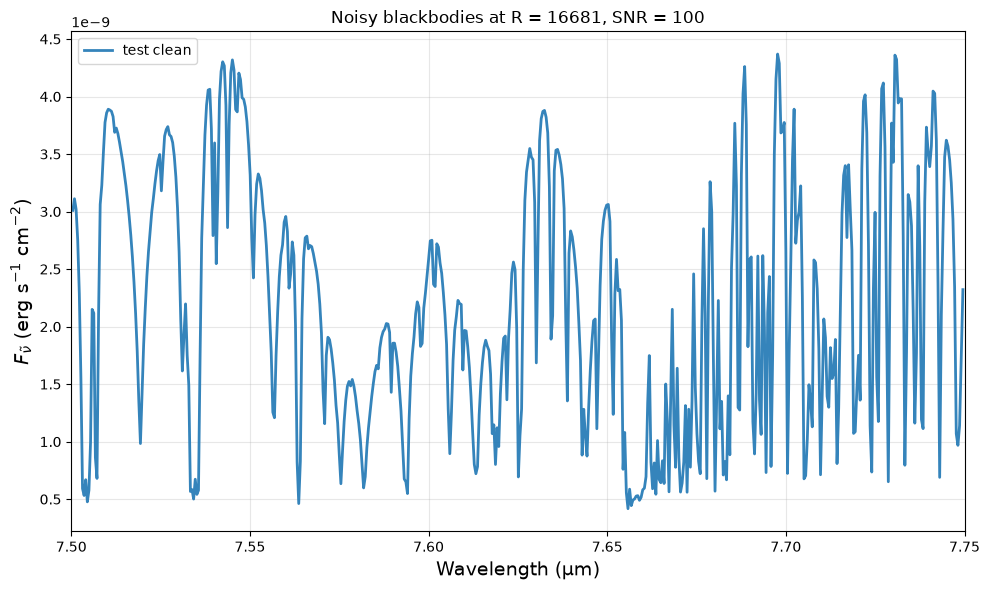

In [8]:
plt.figure(figsize=(10, 6))

plt_min, plt_max = 7.5,7.75
R = 16681
snr = 100
R_key = int(R)

names = ["test"]
colors = ["C0", "C1"]

for name, color in zip(names, colors):
    d = res_dict[name][R_key]
    x = np.asarray(d["wavelength_grid"], dtype=np.float64)
    y = np.asarray(d[f"flux_snr{snr}"], dtype=np.float64)
    # err = np.asarray(d[f"error_clean"], dtype=np.float64)
    
    print(f"{name}: {np.std(y)}")

    m = np.isfinite(x) & np.isfinite(y) & (y > 0) & (x >= plt_min) & (x <= plt_max)
    # x, y, err = x[m], y[m], err[m]

    # plt.errorbar(
    #     x, y, yerr=err,
    #     label=f"{name} noisy (R={int(R)}, SNR={snr})",
    #     marker="o", ls="none", markersize=4, capsize=3,
    #     alpha=0.7, color=color, zorder=1,
    # )

    y_c = np.asarray(d["flux_clean"], dtype=np.float64)
    m_c = np.isfinite(x)
    x_c = np.asarray(d["wavelength_grid"], dtype=np.float64)
    y_c = np.asarray(d["flux_clean"], dtype=np.float64)
    m_c = np.isfinite(x_c) & np.isfinite(y_c) & (y_c > 0) & (x_c >= plt_min) & (x_c <= plt_max)
    plt.plot(x_c[m_c], y_c[m_c], lw=2, color=color, alpha=0.9, zorder=2,
             label=f"{name} clean")

# plt.yscale("log")
plt.xlim(plt_min, plt_max)
# plt.ylim(1.95e-11,2.0e-11)
plt.xlabel("Wavelength (µm)", fontsize=14)
plt.ylabel(
    r"$F_{\tilde{\nu}}$ (erg s$^{-1}$ cm$^{-2}$)",
    fontsize=14,
)
plt.title(f"Noisy blackbodies at R = {int(R)}, SNR = {snr}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

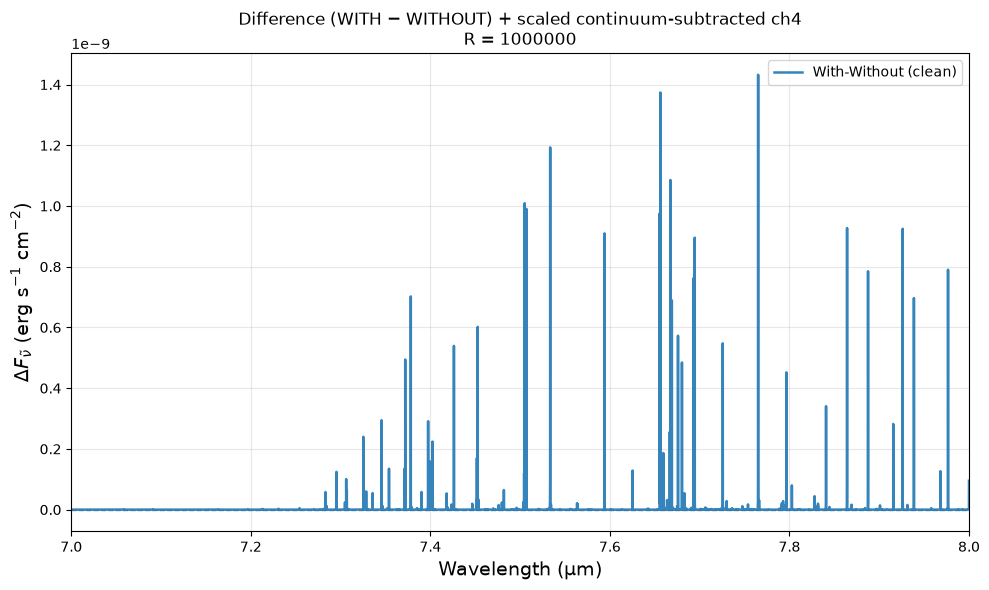

In [40]:
plt.figure(figsize=(10, 6))
plt_min, plt_max = 7, 8
R = 1000000
snr = 10
R_key = int(R)
mol_of_interest = "ch4"

# --- difference spectrum (WITH − WITHOUT) ---
d_with = res_dict[f"with_{mol_of_interest}_r1"][R_key]
d_without = res_dict[f"without_{mol_of_interest}_r1"][R_key]

x = np.asarray(d_with["wavelength_grid"], dtype=np.float64)
y_with = np.asarray(d_with["flux_snr"], dtype=np.float64)
y_without = np.asarray(d_without["flux_clean"], dtype=np.float64)

m = (
    np.isfinite(x)
    & np.isfinite(y_with)
    & np.isfinite(y_without)
    & (y_with > 0)
    & (y_without > 0)
    & (x >= plt_min)
    & (x <= plt_max)
)

diff = y_with[m] - y_without[m]

plt.plot(
    x[m],
    np.abs(diff),
    lw=1.8,
    color="C0",
    alpha=0.9,
    label="With-Without (clean)",
)

# # --- pure DMS: continuum-subtract + scale ---
# d_dms = res_dict["CH4"][R_key]
# x_dms = np.asarray(d_dms["wavelength_grid"], dtype=np.float64)
# y_dms = np.asarray(d_dms["flux_clean"], dtype=np.float64)

# d_bb = res_dict["BLACKBODY"][R_key]
# x_bb = np.asarray(d_bb["wavelength_grid"], dtype=np.float64)
# y_bb_raw = np.asarray(d_bb["flux_clean"], dtype=np.float64)

# if not np.all(np.diff(x_bb) > 0):
#     raise ValueError("Blackbody wavelength grid is not strictly increasing")

# y_bb = np.interp(x_dms, x_bb, y_bb_raw)

# m_dms = (
#     np.isfinite(x_dms)
#     & np.isfinite(y_dms)
#     & np.isfinite(y_bb)
#     & (x_dms >= plt_min)
#     & (x_dms <= plt_max)
# )

# dms_residual = y_dms[m_dms] - y_bb[m_dms]

# ---------- scaling ----------
# Option A: manual scale (easiest to tune by eye)
scale = 1.0          # <--- change this number until the features line up

# Option B: automatic scale that matches the deepest trough
# (uncomment the next two lines if you prefer this)
# deepest_diff = np.min(diff)
# deepest_dms  = np.min(dms_residual)
# scale = deepest_diff / deepest_dms if deepest_dms != 0 else 1.0

# dms_scaled = dms_residual * scale

# plt.plot(
#     x_dms[m_dms],
#     dms_scaled,
#     lw=1.5,
#     color="C1",
#     alpha=0.85,
#     ls="--",
#     label=f"DMS − BB (scaled ×{scale:.3g})",
# )

plt.axhline(0, color="k", ls="--", lw=1, alpha=0.5, zorder=0)
# plt.yscale("log")
plt.xlim(plt_min, plt_max)
plt.xlabel("Wavelength (µm)", fontsize=14)
plt.ylabel(
    r"$\Delta F_{\tilde{\nu}}$ (erg s$^{-1}$ cm$^{-2}$)",
    fontsize=14,
)
plt.title(f"Difference (WITH − WITHOUT) + scaled continuum-subtracted {mol_of_interest}\nR = {int(R)}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
print(res_dict['with_ch4_r1'][16681].keys())

dict_keys(['wavelength_grid', 'flux_clean', 'resolution', 'flux_snr1', 'error_snr1', 'flux_snr2', 'error_snr2', 'flux_snr4', 'error_snr4', 'flux_snr10', 'error_snr10', 'flux_snr21', 'error_snr21', 'flux_snr46', 'error_snr46', 'flux_snr100', 'error_snr100', 'flux_snr215', 'error_snr215', 'flux_snr464', 'error_snr464', 'flux_snr1000', 'error_snr1000'])


## Spectra plot

In [ ]:
def plot_comparison_grid(
    res_dict,
    resolutions,
    snrs,
    wl_min,
    wl_max,
    df_cc=None,
    mol_of_interest="Isoprene",
    scen_with=None,
    scen_without=None,
    show_errors=True,
    figsize=None,
    min_points=2,
):
    if scen_with is None:
        scen_with = f"ALL_WITH_{mol_of_interest}"#f"with_{mol_of_interest}_r1"
    if scen_without is None:
        scen_without = f"ALL_WITHOUT_{mol_of_interest}"#f"without_{mol_of_interest}_r1"

    resolutions = list(resolutions)
    snrs = list(snrs)
    nrows, ncols = len(snrs), len(resolutions)
    if figsize is None:
        figsize = (4.2 * ncols, 3.2 * nrows)

    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize, sharex=False, sharey=False, squeeze=False
    )

    def lookup_sigma(R, snr):
        if df_cc is None:
            return None
        mask = (
            np.isclose(df_cc["resolution"].astype(float), float(R))
            & np.isclose(df_cc["snr"].astype(float), float(snr))
        )
        sub = df_cc.loc[mask]
        if len(sub) == 0:
            return None
        return float(sub["sigma"].mean())

    def pick_key(d, R):
        if int(R) in d:
            return int(R)
        if R in d:
            return R
        # nearest key
        keys = np.array(list(d.keys()), dtype=float)
        return list(d.keys())[int(np.argmin(np.abs(keys - float(R))))]

    y_all = []  # collect for shared finite ylim

    for i, snr in enumerate(snrs):
        for j, R in enumerate(resolutions):
            ax = axes[i, j]
            try:
                d_with = res_dict[scen_with][pick_key(res_dict[scen_with], R)]
                d_without = res_dict[scen_without][pick_key(res_dict[scen_without], R)]
            except KeyError as e:
                ax.set_visible(False)
                print(f"skip R={R} SNR={snr}: missing key {e}")
                continue

            snr_key = f"flux_snr{int(snr)}"
            err_key = f"error_snr{int(snr)}"
            if snr_key not in d_with:
                ax.set_visible(False)
                print(f"skip R={R} SNR={snr}: no {snr_key}")
                continue

            x_w = np.asarray(d_with["wavelength_grid"], dtype=np.float64)
            y_with_clean = np.asarray(d_with["flux_clean"], dtype=np.float64) 
            y_with_noisy = np.asarray(d_with[snr_key], dtype=np.float64) 
            err_with = (
                np.asarray(d_with[err_key], dtype=np.float64) 
                if err_key in d_with
                else np.zeros_like(y_with_noisy)
            )

            x_o = np.asarray(d_without["wavelength_grid"], dtype=np.float64)
            y_without_clean = np.asarray(d_without["flux_clean"], dtype=np.float64)

            # align lengths if needed
            n = min(len(x_w), len(y_with_clean), len(y_with_noisy), len(err_with))
            x_w, y_with_clean, y_with_noisy, err_with = (
                x_w[:n], y_with_clean[:n], y_with_noisy[:n], err_with[:n]
            )
            n_o = min(len(x_o), len(y_without_clean))
            x_o, y_without_clean = x_o[:n_o], y_without_clean[:n_o]

            m_w = (
                np.isfinite(x_w)
                & np.isfinite(y_with_clean)
                & np.isfinite(y_with_noisy)
                & np.isfinite(err_with)
                & (x_w >= wl_min)
                & (x_w <= wl_max)
            )
            m_o = (
                np.isfinite(x_o)
                & np.isfinite(y_without_clean)
                & (x_o >= wl_min)
                & (x_o <= wl_max)
            )

            if m_w.sum() < min_points and m_o.sum() < min_points:
                ax.set_visible(False)
                print(f"skip R={R} SNR={snr}: <{min_points} points in window")
                continue

            x_w, y_with_clean = x_w[m_w], y_with_clean[m_w]
            y_with_noisy, err_with = y_with_noisy[m_w], err_with[m_w]
            x_o, y_without_clean = x_o[m_o], y_without_clean[m_o]

            if show_errors and len(x_w):
                ax.errorbar(
                    x_w, y_with_noisy, yerr=err_with,
                    marker="o", ls="none", markersize=2, capsize=1,
                    alpha=0.3, color="purple", zorder=3, label="noisy with",
                )
            elif len(x_w):
                ax.plot(
                    x_w, y_with_noisy, ls="none", marker="o", markersize=2,
                    alpha=0.3, color="purple", zorder=3, label="noisy with",
                )

            if len(x_o):
                ax.plot(x_o, y_without_clean, lw=1.5, color="royalblue",
                        zorder=4, label="clean without", alpha = 0.8)
            if len(x_w):
                ax.plot(x_w, y_with_clean, lw=1.5, color="orange",
                        zorder=3, label="clean with")

            y_all.extend(y_with_clean.tolist())
            y_all.extend(y_without_clean.tolist())
            y_all.extend(y_with_noisy.tolist())

            sig = lookup_sigma(R, snr)
            sig_str = f" σ={sig:.2f}" if sig is not None else " σ=n/a"
            ax.set_title(f"R={int(R)}, SNR={int(snr)}{sig_str}", fontsize=10)
            ax.grid(True, alpha=0.3)
            if j == 0:
                ax.set_ylabel(r"$F_{\tilde{\nu}}$")
            ax.set_xlim(wl_min, wl_max)
            # ax.set_ylim(1.10e-08,1.13e-08)

    # finite shared y-limits (avoids NaN from empty axes)
    y_all = np.asarray(y_all, dtype=float)
    y_all = y_all[np.isfinite(y_all)]
    if y_all.size:
        ymin, ymax = np.nanpercentile(y_all, [1, 99])
        pad = 0.05 * (ymax - ymin + 1e-30)
        for ax in axes.ravel():
            if ax.get_visible():
                ax.set_ylim(ymin - pad, ymax + pad)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right", ncol=3, frameon=False)

    fig.suptitle(
        f"{mol_of_interest}: clean with/without + noisy with\n"
        f"[{wl_min}, {wl_max}] µm",
        y=0.98,
        fontsize=13,
    )
    fig.tight_layout()
    plt.show()
    return fig, axes


# example
plot_comparison_grid(
    res_dict,
    resolutions=[278, 774, 16681],
    snrs=[2,21,100],
    wl_min=3.2,
    wl_max=3.8,
    # flux_min=0.0,
    df_cc=df_cc,
    mol_of_interest="CH4",
    show_errors=True,
    figsize = (10,6)
);

In [17]:
# R, snr = 100, 2
# d = res_dict["ALL_WITHOUT_CH4"][R]
# x = np.asarray(d["wavelength_grid"], float)
# y = np.asarray(d["flux_snr2"], float)
# m = np.isfinite(x) & np.isfinite(y) & (x >= 7.2) & (x <= 7.8)
# print("n in window", m.sum(), "x range", x[m].min() if m.any() else None, x[m].max() if m.any() else None)
# print("y finite", np.isfinite(y[m]).all(), "y sample", y[m][:5] if m.any() else None)

# # any NaN wavelengths globally?
# for R in [100, 215, 464]:
#     x = res_dict["ALL_WITH_CH4"][R]["wavelength_grid"]
#     print(R, np.isnan(x).sum(), x.min(), x.max())
    

# Results

## Blackbody test

In [ ]:
template_A="BLACKBODY_1"
template_B="BLACKBODY_2" 
test_scenario="BLACKBODY_3"

df_cc_test = cross_correlate_blackbody_test(
    template_A="BLACKBODY_1",
    template_B="BLACKBODY_2",   
    test_scenario="BLACKBODY_3", 
    wl_min=5.0,
    wl_max=10.0,
)
print(df_cc["delta_logL"].describe())
print(df_cc["delta_logL_per_bin"].describe())

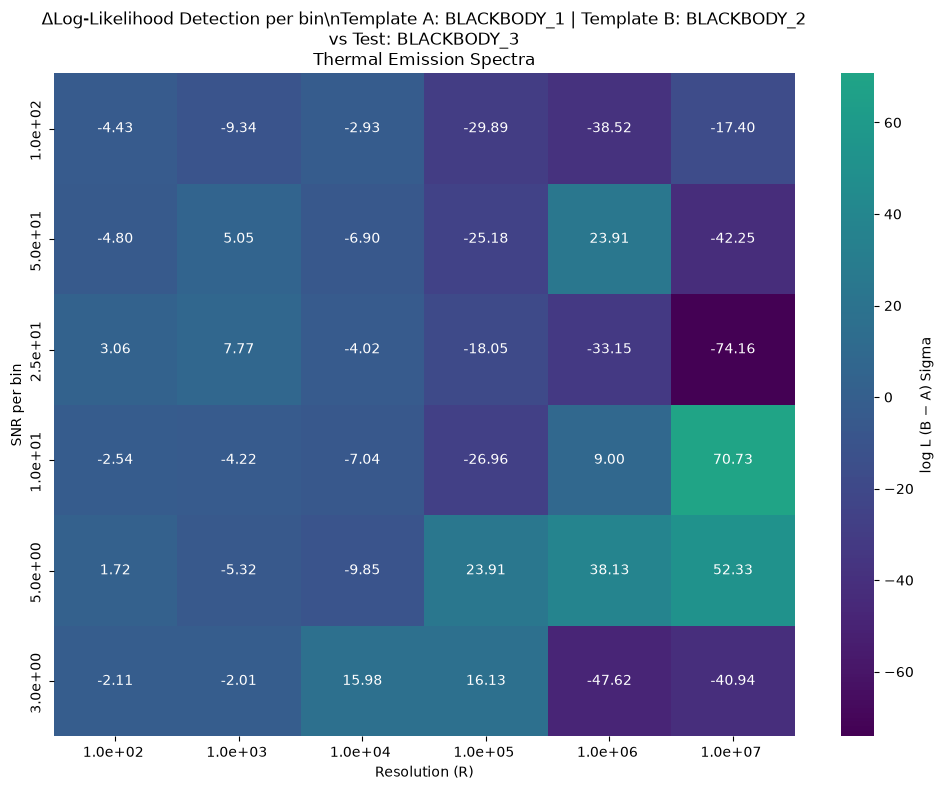

In [35]:
# merged = pd.merge(df_A, df_B, on=['resolution', 'snr'], suffixes=('_A', '_B'))

# Use log-likelihood difference (A - B)
# merged['delta_logL'] = merged['log_lik_B'] - merged['log_lik_A']

# Optional: compute significance (how many sigma the difference is)
# merged['delta_significance'] = merged['delta_logL'] / np.sqrt(merged['noise_std_A']**2 + merged['noise_std_B']**2)

# ======================
# Pivot for heatmap
# ======================
pivot = df_cc_test.pivot_table(
    index='snr', 
    columns='resolution', 
    values='signed_sigma_uncalibrated',        # or 'delta_significance'
    aggfunc='mean'
).sort_index(ascending=False)   # SNR increasing upwards

# ======================
# Annotation
# ======================
annot = pivot.copy().astype(str)

for i, snr in enumerate(pivot.index):
    for j, res in enumerate(pivot.columns):
        val = pivot.iloc[i, j]
        annot.iloc[i, j] = f"{val:.2f}"

# ======================
# Plot
# ======================
plt.figure(figsize=(10, 8))

ax=sns.heatmap(
    pivot,
    cmap='viridis',           
    center=50,
    annot=annot,
    fmt='', 
    cbar_kws={'label': 'log L (B − A) Sigma'}
)



xticklabels = [f"{r:.1e} "
               for r in pivot.columns]
yticklabels = [f"{snr:.1e} "
               for snr in pivot.index]
ax.set_xticklabels(xticklabels)
ax.set_yticklabels(yticklabels)

plt.xlabel('Resolution (R)')
plt.ylabel('SNR per bin')
plt.title(
    r'$\Delta$Log-Likelihood Detection per bin\n'
    f'Template A: {template_A} | Template B: {template_B}\n'
    f'vs Test: {test_scenario}\n'
    'Thermal Emission Spectra'
)

plt.tight_layout()
plt.show()

## Science Cases

In [ ]:
# plt.close('all')
wl_min_cc = 3.2
wl_max_cc = 3.8
# template_A = 'hydrocarbons_without_CH4_r1'
# template_B = 'hydrocarbons_with_CH4_r1' 
# test_scen = 'hydrocarbons_with_CH4_r1'
template_A = 'hydrocarbons_nobg_vmr_normalized_v2_without_ch4'
template_B = 'hydrocarbons_nobg_vmr_normalized_v2_with_ch4' 
test_scen = 'hydrocarbons_nobg_vmr_normalized_v2_with_ch4'
# template_A = 'hydrocarbons_no_bg_earthlike_without_isoprene'
# template_B = 'hydrocarbons_no_bg_earthlike_with_isoprene' 
# test_scen = 'hydrocarbons_no_bg_earthlike_with_isoprene'
df_cc = cross_correlate_two_templates(template_A, template_B, test_scenario=test_scen, wl_min = wl_min_cc, wl_max = wl_max_cc, verbose = False)


In [ ]:


SIGMA_THRESH = 10.0

# ---------- pivot ----------
pivot = (
    df_cc.pivot_table(
        index="snr",
        columns="resolution",
        values="sigma",
        aggfunc="mean",
    )
    .sort_index(ascending=False)  # high SNR at top
)

# numeric annotation
annot = pivot.map(lambda v: f"{v:.1f}" if np.isfinite(v) else "")

# color limits: robust to outliers (optional)
vmax = np.nanpercentile(pivot.values, 90)
vmin = 0.0  # detections only; use None + center=0 if signed null tests

fig, ax = plt.subplots(figsize=(11, 8))

hm = sns.heatmap(
    pivot,
    ax=ax,
    cmap="RdBu_r",
    center = 0,# sequential; use "RdBu_r" + center=0 if signed
    vmin=vmin,
    vmax=vmax,
    annot=annot,
    fmt="",
    linewidths=0.6,
    linecolor="0.9",
    cbar_kws={"label": r"Detection score $\sigma$"},
    square=False,
)

# scientific tick labels
ax.set_xticklabels([f"{r:.0f}" for r in pivot.columns], rotation=0)
ax.set_yticklabels([f"{s:g}" for s in pivot.index], rotation=0)

# ---------- min SNR with σ ≥ 10 per resolution ----------
# heatmap coords: x = column index, y = row index
for j, R in enumerate(pivot.columns):
    col = pivot[R]
    ok = col[col >= SIGMA_THRESH]
    if ok.empty:
        continue
    # lowest SNR that still clears threshold
    snr_star = ok.index.min()
    i = list(pivot.index).index(snr_star)

    # rectangle around that cell (seaborn: cells are 1×1 starting at 0)
    rect = mpatches.Rectangle(
        (j, i), 1, 1,
        fill=False,
        edgecolor="red",
        linewidth=2.5,
        label=rf"min SNR for $\sigma\geq{SIGMA_THRESH:.0f}$" if j == 0 else None,
    )
    ax.add_patch(rect)

# legend only once
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, loc="upper left", frameon=True)

ax.set_xlabel("Resolution (R)")
ax.set_ylabel("SNR per bin")
ax.set_title(
    f"Log-Likelihood Detection Score ({wl_min_cc}–{wl_max_cc} µm)\n"
    f"A: {template_A}  |  B: {template_B}  |  test: {test_scen}\n"
    # f"Gold box = minimum SNR with σ ≥ {SIGMA_THRESH:.0f} (per R)"
)

plt.tight_layout()
plt.show()

# optional: print the threshold track
# print("Min SNR for σ ≥ 10 by resolution:")
# for R in pivot.columns:
#     col = pivot[R]
#     ok = col[col >= SIGMA_THRESH]
#     print(f"  R={R:.0e}: SNR≥{ok.index.min() if len(ok) else 'none'}")

Contours

In [ ]:
# Constants
R_sun = 6.957e8          # m
T_sun = 5800             # K
sigma = 5.67e-8      # Stefan-Boltzmann constant (W m^-2 K^-4)
L_sun = 4 * np.pi * R_sun**2 * sigma * T_sun**4   # ~3.83e26 W

AU = 1.496e11            # m
R_earth = 6.371e6        # m
h = 6.62607015e-34       # Planck's constant (J s)
c = 2.99792458e8         # m/s
pc_to_m = 3.08568e16     # parsec to meters
kB = 1.380649e-23

D_pc = 10.0
D = D_pc * pc_to_m       # distance to system (m)


T_planet = 255.0      # Temp (k)
epsilon = 0.95        # emissivity
sgl_amplification = 1.17e11


P_thermal = epsilon * 4 * np.pi * R_earth**2 * sigma * T_planet**4

# Flux observed
F_thermal_earth = P_thermal / (4 * np.pi * D**2)
print(f"Thermal energy flux at Earth: {F_thermal_earth:.2e} W/m²")

# Photon flux at a representative mid-IR wavelength (e.g. 10 μm)
wl_thermal = 10e-6
E_photon_thermal = h * c / wl_thermal
photon_flux_thermal = F_thermal_earth / E_photon_thermal

photon_flux_thermal_sgl = photon_flux_thermal * sgl_amplification

print(f"Thermal photon flux (~10 μm): {photon_flux_thermal:.5f} photons m⁻² s⁻¹")

In [ ]:
# --- User parameters ---
wl = 550e-9                  # wavelength (m)
t_obs = 300.0                # seconds
sgl_amplification = 1.17e11     
W_r = 15e-6                 
S_nrbin = np.logspace(0, 3, 200)   
num_pix = 1000**2
corona_photons = 1e4 
A_pix = 0.01 #sensor pixel area (m^2)

# Photon numbersgl_amplification
print(f"Total photons N_p = {photon_flux_thermal_sgl:.3e}")
print(f"Conventional photons N_p_conventional = {photon_flux_thermal:.3e}")

#d_lambda according to Slava
d_lambda = ((S_nrbin * np.sqrt(num_pix) * np.sqrt(corona_photons))/(photon_flux_thermal_sgl * np.sqrt(A_pix * t_obs) * 0.891 * 10))**2

# Resolution metric
R = wl/d_lambda
R_conv = wl / W_r * (photon_flux_thermal / S_nrbin**2)

# Plot
plt.figure(figsize=(9, 6))
plt.plot(R, S_nrbin, 'b-', lw=2.5)
# plt.plot(R_conv, S_nrbin, 'r-', lw=2.5, label='Conventional Telescopes')
plt.ylabel('SNR per bin ($S_{\\rm nrbin}$)')
plt.xlabel(r'Spectral Resolution')
plt.title(f'Resolution  vs SNR per bin\n(Earth-like @ {D_pc} pc, SGL gain = {sgl_amplification:.0e})')
plt.grid(True, which='both', ls='--', alpha=0.7)
plt.xscale('log')          # usually needed
plt.tight_layout()
plt.show()

In [ ]:

# Sort by R for a clean line
order = np.argsort(R)
R_line = np.asarray(R, dtype=float)[order]
snr_line = np.asarray(S_nrbin, dtype=float)[order]

# ========== 2) Heatmap pivot (your existing code) ==========
SIGMA_THRESH = 10.0

pivot = (
    df_cc.pivot_table(
        index="snr",
        columns="resolution",
        values="sigma",
        aggfunc="mean",
    )
    .sort_index(ascending=False)  # high SNR at top
)

annot = pivot.map(lambda v: f"{v:.1f}" if np.isfinite(v) else "")
vmax = np.nanpercentile(pivot.values, 90)
vmin = 0.0

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    pivot,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=vmin,
    vmax=vmax,
    annot=annot,
    fmt="",
    linewidths=0.6,
    linecolor="0.9",
    cbar_kws={"label": r"Detection significance $\sigma$"},
)

ax.set_xticklabels([f"{r:.0e}" for r in pivot.columns], rotation=0)
ax.set_yticklabels([f"{s:g}" for s in pivot.index], rotation=0)

# ========== 3) Map continuous (R, SNR) → heatmap cell centers ==========
R_cols = np.asarray(pivot.columns, dtype=float)
snr_rows = np.asarray(pivot.index, dtype=float)  # high → low if ascending=False

# index space: column j ↔ R_cols[j], row i ↔ snr_rows[i]
x_from_R = interp1d(
    R_cols, np.arange(len(R_cols), dtype=float),
    kind="linear", bounds_error=False, fill_value=np.nan,
)
y_from_snr = interp1d(
    snr_rows, np.arange(len(snr_rows), dtype=float),
    kind="linear", bounds_error=False, fill_value=np.nan,
)

x = x_from_R(R_line) + 0.5   # cell centers
y = y_from_snr(snr_line) + 0.5
m = np.isfinite(x) & np.isfinite(y)

ax.plot(
    x[m], y[m],
    color="cyan",
    lw=2.5,
    label=f"SGL SNR–$R$ contour, Tiles = {num_pix:.0e}",
    zorder=2,
)

for j, Rv in enumerate(pivot.columns):
    col = pivot[Rv]
    ok = col[col >= SIGMA_THRESH]
    if ok.empty:
        continue
    snr_star = ok.index.min()
    i = list(pivot.index).index(snr_star)
    rect = mpatches.Rectangle(
        (j, i), 1, 1,
        fill=False, edgecolor="red", linewidth=2.5,
        label=rf"min SNR for $\sigma\geq{SIGMA_THRESH:.0f}$" if j == 0 else None,
    )
    ax.add_patch(rect)

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, loc="upper right", frameon=True)

ax.set_xlabel("Spectral Resolution")
ax.set_ylabel("SNR per bin")
ax.set_title(
    f"Log-Likelihood Detection Score ({wl_min_cc}–{wl_max_cc} µm)\n"
    # f"A: {template_A} | B: {template_B} | test: {test_scen}"
)
plt.tight_layout()
plt.show()

In [ ]:
# adjustable
R     = 1e6
SNR_R = 10.0

# parameters (edit these)
wl_um     = 0.55          # µm
A_pix     = 1          # m²   (this is still awkward – see note below)
t         = 300.0         # s
Q_cor     = 1e6           # photons s⁻¹ µm⁻²   ← order-of-magnitude from the paper
D_over_d  = 1.0

delta_lambda_um = (wl_um) / R          # µm

N_sig = (SNR_R * np.sqrt(Q_cor * A_pix * delta_lambda_um * t)
         / (0.891 * D_over_d))

print(f"N_sig ≈ {N_sig:.3e}")

In [ ]:
import numpy as np

# ========== adjustable inputs ==========
R     = 1e6      # desired spectral resolving power
SNR_R = 20.0     # desired SNR_R (per pixel, per spectral bin)

# ========== fixed parameters (edit as needed) ==========
wl        = 550e-9   # wavelength (m)
A_pix     = 1     # pixel collecting area (m²)
t         = 300.0    # integration time (s)
Q_cor     = 1e4      # background rate density (same units as Q)
D_over_d  = 1.0     # D/d (you previously absorbed this as the factor of ~10)

# ========== calculation ==========
delta_lambda = wl / R

N_sig = (SNR_R * np.sqrt(Q_cor * A_pix * delta_lambda * t)
         / (0.891 * D_over_d))

print(f"R = {R:.3e}")
print(f"SNR_R = {SNR_R}")
print(f"Δλ = {delta_lambda:.3e} m")
print(f"Required signal photons N_sig = {N_sig:.4e}")

## Mol vs. Black Body Verification

In [53]:
# plt.close('all')
wl_min_cc_vsbb = 10
wl_max_cc_vsbb = 12
template_A = 'BLACKBODY'
template_B = 'DMS' 
test_scen = 'DMS'
df_cc_vsbb = cross_correlate_two_templates(template_A, template_B, test_scenario=test_scen, wl_min = wl_min_cc, wl_max = wl_max_cc, verbose = False)


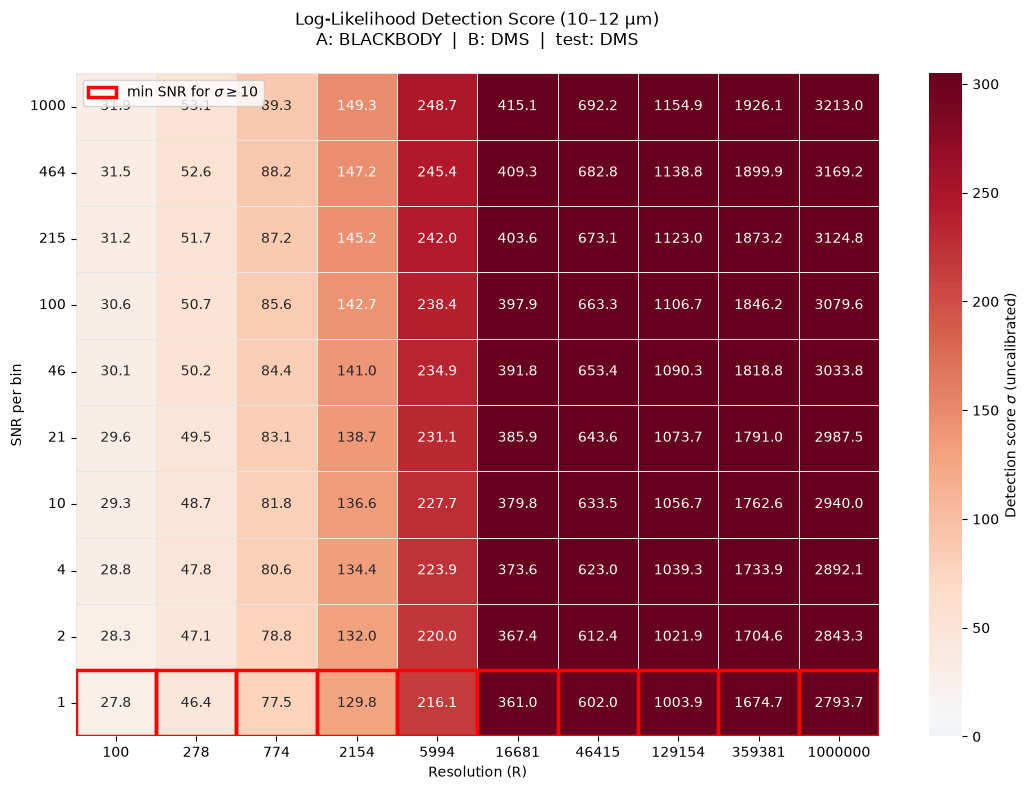

In [54]:


SIGMA_THRESH = 10.0

# ---------- pivot ----------
pivot = (
    df_cc_vsbb.pivot_table(
        index="snr",
        columns="resolution",
        values="sigma",
        aggfunc="mean",
    )
    .sort_index(ascending=False)  # high SNR at top
)

# numeric annotation
annot = pivot.map(lambda v: f"{v:.1f}" if np.isfinite(v) else "")

# color limits: robust to outliers (optional)
vmax = np.nanpercentile(pivot.values, 50)
vmin = 0.0  # detections only; use None + center=0 if signed null tests

fig, ax = plt.subplots(figsize=(11, 8))

hm = sns.heatmap(
    pivot,
    ax=ax,
    cmap="RdBu_r",
    center = 10,# sequential; use "RdBu_r" + center=0 if signed
    vmin=vmin,
    vmax=vmax,
    annot=annot,
    fmt="",
    linewidths=0.6,
    linecolor="0.9",
    cbar_kws={"label": r"Detection score $\sigma$ (uncalibrated)"},
    square=False,
)

# scientific tick labels
ax.set_xticklabels([f"{r:.0f}" for r in pivot.columns], rotation=0)
ax.set_yticklabels([f"{s:g}" for s in pivot.index], rotation=0)

# ---------- min SNR with σ ≥ 10 per resolution ----------
# heatmap coords: x = column index, y = row index
for j, R in enumerate(pivot.columns):
    col = pivot[R]
    ok = col[col >= SIGMA_THRESH]
    if ok.empty:
        continue
    # lowest SNR that still clears threshold
    snr_star = ok.index.min()
    i = list(pivot.index).index(snr_star)

    # rectangle around that cell (seaborn: cells are 1×1 starting at 0)
    rect = mpatches.Rectangle(
        (j, i), 1, 1,
        fill=False,
        edgecolor="red",
        linewidth=2.5,
        label=rf"min SNR for $\sigma\geq{SIGMA_THRESH:.0f}$" if j == 0 else None,
    )
    ax.add_patch(rect)

# legend only once
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, loc="upper left", frameon=True)

ax.set_xlabel("Resolution (R)")
ax.set_ylabel("SNR per bin")
ax.set_title(
    f"Log-Likelihood Detection Score ({wl_min_cc}–{wl_max_cc} µm)\n"
    f"A: {template_A}  |  B: {template_B}  |  test: {test_scen}\n"
    # f"Gold box = minimum SNR with σ ≥ {SIGMA_THRESH:.0f} (per R)"
)

plt.tight_layout()
plt.show()

# optional: print the threshold track
# print("Min SNR for σ ≥ 10 by resolution:")
# for R in pivot.columns:
#     col = pivot[R]
#     ok = col[col >= SIGMA_THRESH]
#     print(f"  R={R:.0e}: SNR≥{ok.index.min() if len(ok) else 'none'}")